# Multivariate linear regression

In this notebook, we will apply linear regression to experimental data relating mix design variables to the compressive strength of high-performance concrete.
The dataset is taken from the paper "Modeling of strength of high-performance concrete using artificial neural networks" DOI:10.1016/S0008-8846(98)00165-3

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### Utility function: parity plot

A parity plot compares:

- True experimental values
- Predicted values from the model

If predictions are perfect, all points lie on the diagonal.

In [2]:
def parity_plot(y_true, y_pred, title="Parity Plot"):
    plt.figure()
    
    # Scatter plot: true vs predicted
    plt.scatter(y_true, y_pred, s=80, c='k', marker='x', linewidth=0.7, zorder=1)

    # For large datasets, individual scatter points may overlap, making it difficult to assess the distribution of predictions. 
    # Hexagonal binning addresses this issue by grouping points into bins and visualizing their frequency through color intensity. 
    # The associated colorbar indicates the number of samples within each bin.
    # hb = plt.hexbin(y_true, y_pred, zorder=-1, cmap='gray_r', mincnt=1, gridsize=12, edgecolors='none')
    # cb = plt.colorbar(hb)
    # cb.set_label("Counts per bin")
    
    # Ideal line (perfect prediction)
    min_val = min(np.min(y_true), np.min(y_pred))
    max_val = max(np.max(y_true), np.max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'goldenrod', linewidth=1.5, zorder=1, linestyle='--')

    plt.xlim([min_val, max_val])
    plt.ylim([min_val, max_val])
    plt.xlabel("True strength [MPa]")
    plt.ylabel("Predicted strength [MPa]")
    plt.title(title)

    # Mean squarred error
    mse = np.mean((y_true - y_pred)**2)
    # R^2 score (coefficient of determination)
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)
    
    plt.text(min_val, max_val, f"MSE = {mse:.3f}\nR² = {r2:.3f}",
             verticalalignment='top')
    
    plt.show()

### Load data

In [3]:
# Load data from Excel
file_path = "../Data/Concrete/Concrete.xls"
df = pd.read_excel(file_path)
# The dataset is stored in Excel format (.xls).
# Pandas requires the 'xlrd' package to read this format.
# If you get an error, install it via: pip install xlrd.

# Display the first rows of the dataset
df.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


### Define inputs and outputs

In [4]:
# In this dataset, the last column is the concrete compressive strength target
X = df.iloc[1:, :-1].values   # All columns except last → input features
y = df.iloc[1:, -1].values    # Last column → target

N, d = X.shape
print(f"\nNumber of samples: {N}")
print(f"Number of features: {d}")


Number of samples: 1029
Number of features: 8


### Exploring the data we observe concrete features have very different scales, e.g.:

- Cement: ~100–500
- Water: ~100–200
- Age: ~1–365
- Superplasticizer: ~0–20

### It is important to normalize the data!

We standardize the input features to have:

- zero mean
- unit variance

This improves numerical stability and ensures all variables contribute equally to the regression.

In [5]:
# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

# Standardization
scaler = StandardScaler()

# Fit standardization statistics ONLY on the training data
X_train_scaled = scaler.fit_transform(X_train) # Fit and transform with the same instruction

# Apply same transformation to test data
X_test_scaled = scaler.transform(X_test)

### Train model (least squares)

In [6]:
# Build design matrix by adding bias term (column of ones)
X_train_d = np.hstack([np.ones((X_train_scaled.shape[0], 1)), X_train_scaled])
X_test_d  = np.hstack([np.ones((X_test_scaled.shape[0], 1)), X_test_scaled])

# The pseudo-inverse is numerically more stable than (X^T @ X)^-1 @ X^T
beta = np.linalg.pinv(X_train_d) @ y_train
print("Estimated parameters:")
print(beta)

Estimated parameters:
[35.85354033 12.26577611  8.68078427  5.47164591 -3.65404759  1.59071011
  1.12470811  1.42448233  7.35888421]


### Prediction and visualization 

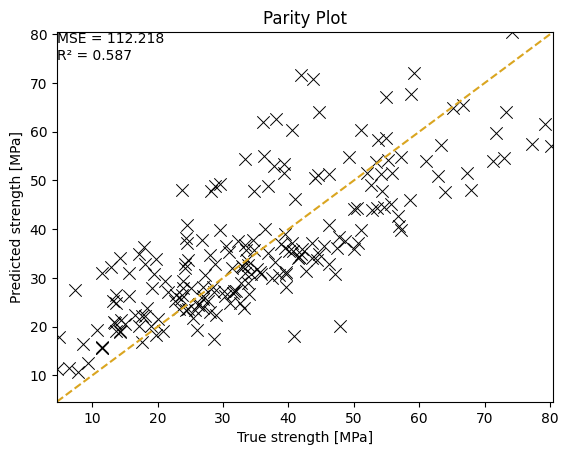

In [7]:
# Predictions
y_train_pred = X_train_d @ beta
y_test_pred  = X_test_d @ beta

# Visualization by means of our utility function
parity_plot(y_test, y_test_pred)

### More compact option using scikit-learn

Intercept: 35.853540331653065
Coefficients: [ 0.         12.26577611  8.68078427  5.47164591 -3.65404759  1.59071011
  1.12470811  1.42448233  7.35888421]


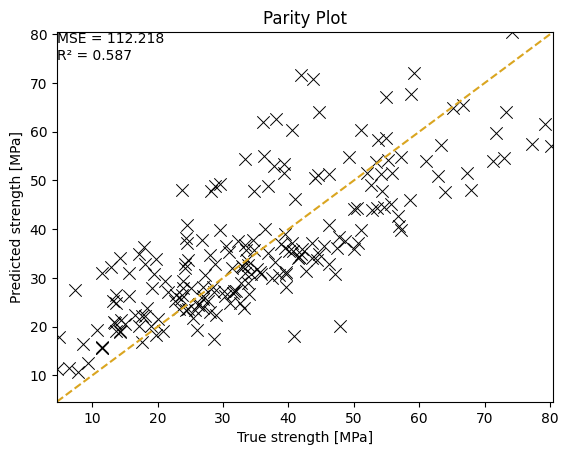

In [8]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_d, y_train)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

y_test_pred = model.predict(X_test_d)
parity_plot(y_test, y_test_pred)

### Results interpretation:

#### What can we conclude about the performance of the linear model?

- MSE small → good fit (metric is problem-dependent) 
- R² close to 1 → model explains variance well (metric is problem-independent)

#### Are we satisfied enough about the performance of the linear model?